⏰ TIME STEP ANALYSIS for Labeled Dataset(Feature 1)
Min time step: 1
Max time step: 49
Number of unique time steps: 49


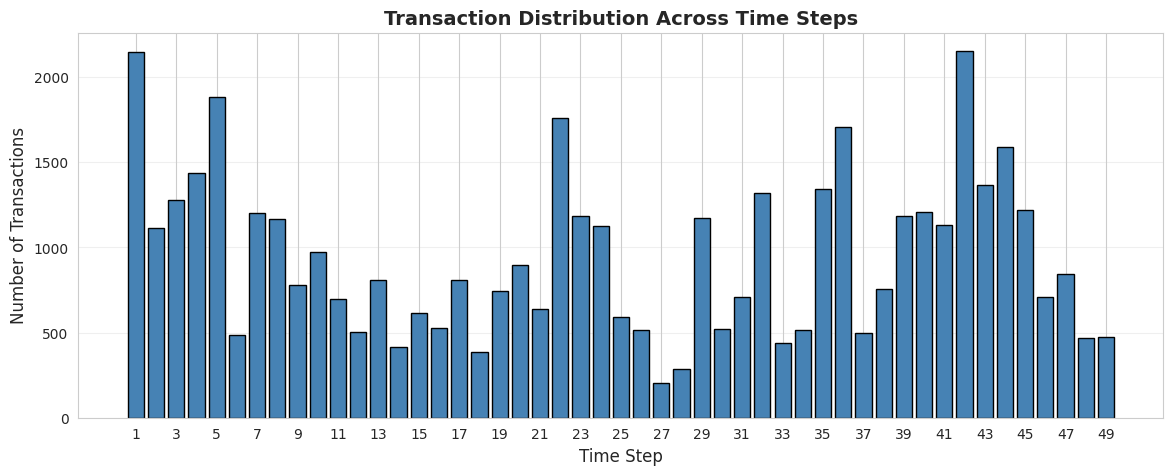


✂️ Splitting Train/Test Labeled Dataset by temporal split...
Train dataset shape: (37723, 168)
Test dataset shape: (8841, 168)

🎨 Creating temporal validation split...
✅ Validation splitting is done.


In [76]:
print("⏰ TIME STEP ANALYSIS for Labeled Dataset(Feature 1)")
print("="*60)

print(f"Min time step: {random_forest_df["time_step"].min()}")
print(f"Max time step: {random_forest_df["time_step"].max()}")
print(f"Number of unique time steps: {random_forest_df["time_step"].nunique()}")

# Transactions per time step
time_dist = random_forest_df["time_step"].value_counts().sort_index()

plt.figure(figsize=(14, 5))
plt.bar(time_dist.index, time_dist.values, color='steelblue', edgecolor='black')
plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.title('Transaction Distribution Across Time Steps', fontsize=14, fontweight='bold')
plt.xticks(range(1, 50, 2))
plt.grid(axis='y', alpha=0.3)
plt.show()

print("\n✂️ Splitting Train/Test Labeled Dataset by temporal split...")
train_period_df = random_forest_df[random_forest_df["time_step"] <= 41].copy()
test_period_df = random_forest_df[random_forest_df["time_step"] >= 42].copy()
print(f"Train dataset shape: {train_period_df.shape}")
print(f"Test dataset shape: {test_period_df.shape}\n")

print("🎨 Creating temporal validation split...")
train_validation_df = train_period_df[train_period_df["time_step"] <= 34].copy()
validation_df = train_period_df[train_period_df["time_step"] >= 35].copy()
print("✅ Validation splitting is done.")


In [77]:
print("🛠️ Creating train, validation and test sets with separated features and labels")
feature_columns = [
    col for col in random_forest_df.columns
    if col not in ["txId", "time_step", "is_illicit"]
]

X_train_temporal = train_validation_df[feature_columns]
y_train_temporal = train_validation_df["is_illicit"]

X_val_temporal = validation_df[feature_columns]
y_val_temporal = validation_df["is_illicit"]

X_test_temporal = test_period_df[feature_columns]
y_test_temporal = test_period_df["is_illicit"]
print("✅ Done!")


🛠️ Creating train, validation and test sets with separated features and labels
✅ Done!


In [78]:
import random
from itertools import product 
from sklearn.metrics import roc_auc_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

print("🔎 Hyperparameter search\n")
rf_temporal_params = {
    "n_estimators": list(range(150, 750, 50)),
    "max_depth": [10, 15, 20, 25, 30, None],
    "min_samples_split": list(range(5, 51, 5)),
    "min_samples_leaf": list(range(2, 16)),
    "max_features": [0.3, 0.5, "sqrt"],
}
# Params values range based on the first experiment with random data split
# rf_temporal_params = {
#     "n_estimators": [450, 500, 550, 568, 600, 650],
#     "max_depth": [15, 18, 20, 22, 25],
#     "min_samples_split": [8, 10, 12, 15, 18],
#     "min_samples_leaf": [1, 2, 3, 4],
#     "max_features": [0.3, 0.5, "sqrt"]
# }

# Produce a Cartesian product of all given iterables
print("✨ Creating all posibles variations of hyperparameters combinations\n")
param_combinations = list(
    product(
        rf_temporal_params["n_estimators"],
        rf_temporal_params["max_depth"],
        rf_temporal_params["min_samples_leaf"],
        rf_temporal_params["min_samples_split"],
        rf_temporal_params["max_features"],
    )
)

print("🎯 Selecting 30 random hyperparameters combinations")
# Select 30 random sets of hyperparameters
random.seed(42)
selected_params = random.sample(param_combinations, 30)

🔎 Hyperparameter search

✨ Creating all posibles variations of hyperparameters combinations

🎯 Selecting 30 random hyperparameters combinations


In [29]:
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

thresholds = [
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60,
    0.65,
    0.70,
]

results = []

for threshold in thresholds:

    y_pred = (exp2a_probs >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test_temporal,
        y_pred
    ).ravel()

    results.append({
        "threshold": threshold,
        "precision": precision_score(y_test_temporal, y_pred),
        "recall": recall_score(y_test_temporal, y_pred),
        "f1": f1_score(y_test_temporal, y_pred),
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "true_negatives": tn
    })

threshold_results = pd.DataFrame(results)

print(threshold_results)

    threshold  precision    recall        f1  false_positives  \
0        0.10   0.186047  0.941176  0.310680             1680   
1        0.15   0.279070  0.794118  0.413002              837   
2        0.20   0.392387  0.656863  0.491292              415   
3        0.25   0.532438  0.583333  0.556725              209   
4        0.30   0.683386  0.534314  0.599725              101   
5        0.35   0.756364  0.509804  0.609078               67   
6        0.40   0.827731  0.482843  0.609907               41   
7        0.45   0.898148  0.475490  0.621795               22   
8        0.50   0.919431  0.475490  0.626817               17   
9        0.55   0.945813  0.470588  0.628478               11   
10       0.60   0.960000  0.470588  0.631579                8   
11       0.65   0.969697  0.470588  0.633663                6   
12       0.70   0.979381  0.465686  0.631229                4   

    false_negatives  true_positives  true_negatives  
0                24             384

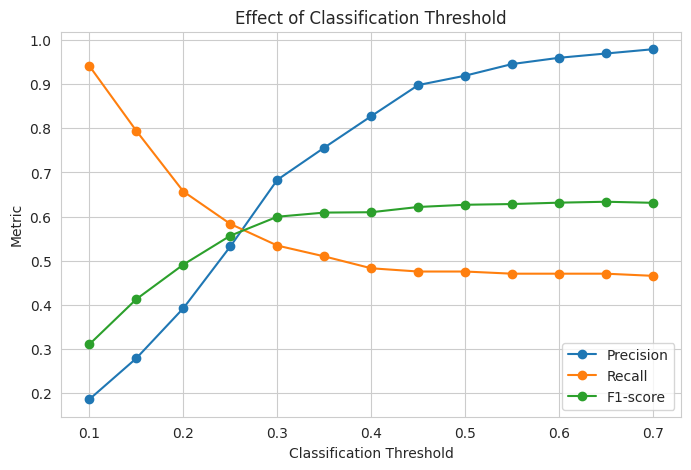

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["f1"],
    marker="o",
    label="F1-score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Metric")

plt.title("Effect of Classification Threshold")

plt.grid(True)
plt.legend()

plt.show()

In [35]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test_temporal,
    exp2a_probs
)

import numpy as np

target_recall = 0.70

idx = np.where(recall >= target_recall)[0]

best_threshold = thresholds[idx[-1]]

print(best_threshold)

y_pred_custom = (
    exp2a_probs >= best_threshold
).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(
    y_test_temporal,
    y_pred_custom
))

print(confusion_matrix(
    y_test_temporal,
    y_pred_custom
))

0.18724296715363728
              precision    recall  f1-score   support

           0       0.98      0.94      0.96      8433
           1       0.37      0.70      0.48       408

    accuracy                           0.93      8841
   macro avg       0.68      0.82      0.72      8841
weighted avg       0.96      0.93      0.94      8841

[[7940  493]
 [ 122  286]]
